# ONLINE RETAIL SALES ANALYSIS

**Goal-**
- Perform exploratory data analysis on the Online Retail transactional dataset to:
- Clean and prepare the data (handle missing values, duplicates, and invalid quantities/prices)
- Calculate revenue and understand key sales metrics
- Identify top-selling and high-value products
- Analyze monthly sales trends and average order value
- Examine customer-level revenue and distinguish between one-time vs repeated customers
- Explore sales performance by country

**Flow of the file-**
- Data cleaning -> Quick look at some data ranking -> New Revenue Column -> Monthly Analysis -> Country based Analysis -> Analysis of customer type -> Graphs

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("online_retail.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


There are total of 1067371 rows and 8 columns in this dataset

## 1. Data Cleaning

Cleaning out all the null rows and duplicate rows/columns from the csv file

In [34]:
print("Null counts (columns with nulls only):")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Null counts (columns with nulls only):
Description      4382
Customer ID    243007
dtype: int64

Duplicate rows: 34335


There are total of 247389 null rows and 34335 duplicate rows 

In [35]:
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"\nShape after cleaning: {df.shape}")


Shape after cleaning: (797885, 8)


The shape of the csv file after clearing up the null and duplicate rows is 
797885 rows and 8 columns

## 2. Removing the items with negetive Quantities and Price

Filtering out the data even more by removing the rows with bad/poor data (negetive quantiy and price)

In [36]:
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

## 3. Quick look : The Most and the Least sold item

1) Sorting the data according to the Quantity highest to lowest (top 5)

In [37]:
df.sort_values(by="Quantity", ascending=False).head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
797411,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
433791,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
64457,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark
93055,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark
93053,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark


**Conclusion** : The most sold item is paper craft,little birdie which has sold upto 80995 

2) Sorting the data according to the Quantity lowest to higest (top 5)

In [38]:
df.sort_values(by="Quantity").head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
797824,581580,22695,WICKER WREATH SMALL,1,2011-12-09 12:20:00,0.59,12748.0,United Kingdom
797823,581580,23126,FELTCRAFT GIRL AMELIE KIT,1,2011-12-09 12:20:00,4.95,12748.0,United Kingdom
797822,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom
797821,581580,23338,EGG FRYING PAN RED,1,2011-12-09 12:20:00,2.08,12748.0,United Kingdom
797820,581580,20974,12 PENCILS SMALL TUBE SKULL,1,2011-12-09 12:20:00,0.65,12748.0,United Kingdom


**Conclusion**: There are many items which have sold only one quantity 

## 4. Quick Look: Most and Least Expensive item

In [39]:
df.nlargest(1, 'Price')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
99582,502263,M,Manual,1,2010-03-23 15:22:00,10953.5,12918.0,United Kingdom


**Conclusion**: The most expensive item in the online retail is listed above which has the price of 10953

In [40]:
df.nsmallest(1, 'Price')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
42295,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.001,16705.0,United Kingdom


**Conclusion**: The least expensive item in the online retail is PADS which has the price of 0.001

## 5. Revenue Calculation per order

Created a new column called "Revenue" which is the total revenue genrated by a product at a time

In [41]:
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Down are the top 5 product which have genrated the highest revenue

In [42]:
df.nlargest(5, "Revenue")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
797411,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6
433791,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
553676,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.0
341726,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.4
99582,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.5


**Conclusion**: The product which have genrated the higest revenue is paper craft,little birdie which is also the product which is purchased in the highest quantity

## 

## 6. Montly Sales

The analysis made on basis of monthly online busniess

In [43]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.strftime("%d %B %Y")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01 December 2009,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01 December 2009,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01 December 2009,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01 December 2009,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01 December 2009,1.25,13085.0,United Kingdom,30.0


Updated the invoice date and made it more readable 

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
x = df["InvoiceDate"].dt.month_name()
res = df.groupby(x)["Revenue"].sum().reset_index().sort_values(by="Revenue", ascending=False)
res.columns = ["Invoice Month", "Total Revenue"]
res

**Conclusion**: The month which has genrated the most revenue is November and the month which genrated the least revenue is February

In [ ]:
res = df.groupby(x)["Revenue"].mean().reset_index().sort_values(by="Revenue", ascending=False)
res.columns = ["Invoice Month", "Average Revenue"]
res

,Invoice Month,Average Revenue
4,January,26.478443
2,December,24.272433
11,September,24.116213
1,August,23.595215
8,May,22.647471
6,June,22.501774
5,July,22.334312
3,February,22.239365
7,March,22.012212
0,April,21.523959


**Conclusion**: The month which has genrated the most average revenue is January and the month which genrated the least revenue is November which has genrated the most total revenue

## 7. Revenue per customer

In [ ]:
df.groupby("Customer ID")["Revenue"].sum().reset_index()

,Customer ID,Revenue
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40
...,...,...
5873,18283.0,2664.90
5874,18284.0,461.68
5875,18285.0,427.00
5876,18286.0,1296.43


**Conclusion**: The customer with customer id 12346 has purchased the most through online retail which is 77556.46 and the customer with customer id 18287 has purchased the least that is 4182.99

## 8. Country-Based Analysis

In [ ]:
df.groupby("Country")["Revenue"].sum().reset_index().round(0).sort_values(by="Revenue" , ascending=False)

,Country,Revenue
38,United Kingdom,14389235.0
10,EIRE,616571.0
24,Netherlands,554038.0
14,Germany,425020.0
13,France,348769.0
0,Australia,169283.0
32,Spain,108332.0
34,Switzerland,100062.0
33,Sweden,91516.0
9,Denmark,68581.0


**Conclusion**: The country with the most total revenue is United Kingdom which made a total of 14389235 in revenue and the country with the least total revenue is Nigeria which made 140 in revenue

In [ ]:
df.groupby("Country")["Customer ID"].nunique().reset_index().astype({"Customer ID": int}).sort_values(by="Customer ID", ascending=False)


,Country,Customer ID
38,United Kingdom,5350
14,Germany,107
13,France,95
32,Spain,41
3,Belgium,29
28,Portugal,24
34,Switzerland,22
24,Netherlands,22
33,Sweden,19
18,Italy,17


**Conclusion**: The country with the most customers is United Kingdom which has a total of 5350 customers and the country with the least customers is Saudi Arabia which has only 1 customers

In [ ]:
df.groupby("Country")["Revenue"].mean().reset_index().round(0).sort_values(by="Revenue" , ascending=False)

,Country,Revenue
24,Netherlands,109.0
0,Australia,95.0
19,Japan,92.0
9,Denmark,88.0
31,Singapore,75.0
33,Sweden,69.0
26,Norway,44.0
10,EIRE,40.0
35,Thailand,40.0
21,Lebanon,38.0


**Conclusion**: The country with the most average revenue is NetherLands which made average revenue of 109 and the country with the least average revenue is Nigeria which made average revenue of 5

## 9. Repeated Customers

Created 2 new columns called Customer Type and Repeated Customer . The ccolumn Repeated customer is a boolean which shows wheather the the customer id is repeated or not and the other column customer Type shows the actual truth about what type of customer is that


In [ ]:
df["Repeated Customer"] = df.groupby("Customer ID")["Customer ID"].transform("count") > 1

df["CustomerType"] = np.where(
    df["Repeated Customer"],
    "Repeated Customer",
    "One Time Customer"
)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Repeated Customer,CustomerType
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085.0,United Kingdom,83.4,True,Repeated Customer
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom,81.0,True,Repeated Customer
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom,81.0,True,Repeated Customer
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085.0,United Kingdom,100.8,True,Repeated Customer
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.0,United Kingdom,30.0,True,Repeated Customer


## 10. Visuals

1) This graph shows the the competition between Uk and Non-uk contries on the basis of total revenue

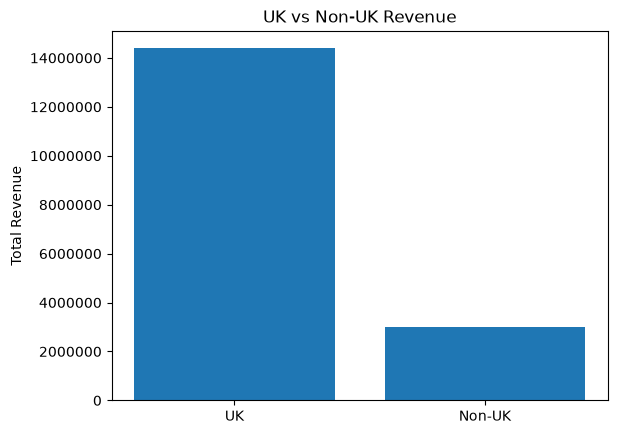

In [ ]:
Uk = df[df["Country"] == "United Kingdom"]["Revenue"].sum()
Non_Uk = df[df["Country"] != "United Kingdom"]["Revenue"].sum()

plt.bar(["UK", "Non-UK"], [Uk, Non_Uk])
plt.ylabel("Total Revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.title("UK vs Non-UK Revenue")

plt.savefig("UK VS Non UK Comparision on basis of total Revenue")
plt.show()


**Conclusion**: The diffrence between the total revenue of UK and other countries is very large . UK has more total revenue than entire other country's total revenue

2) This Graph compares the average revenue of all the 40 contries

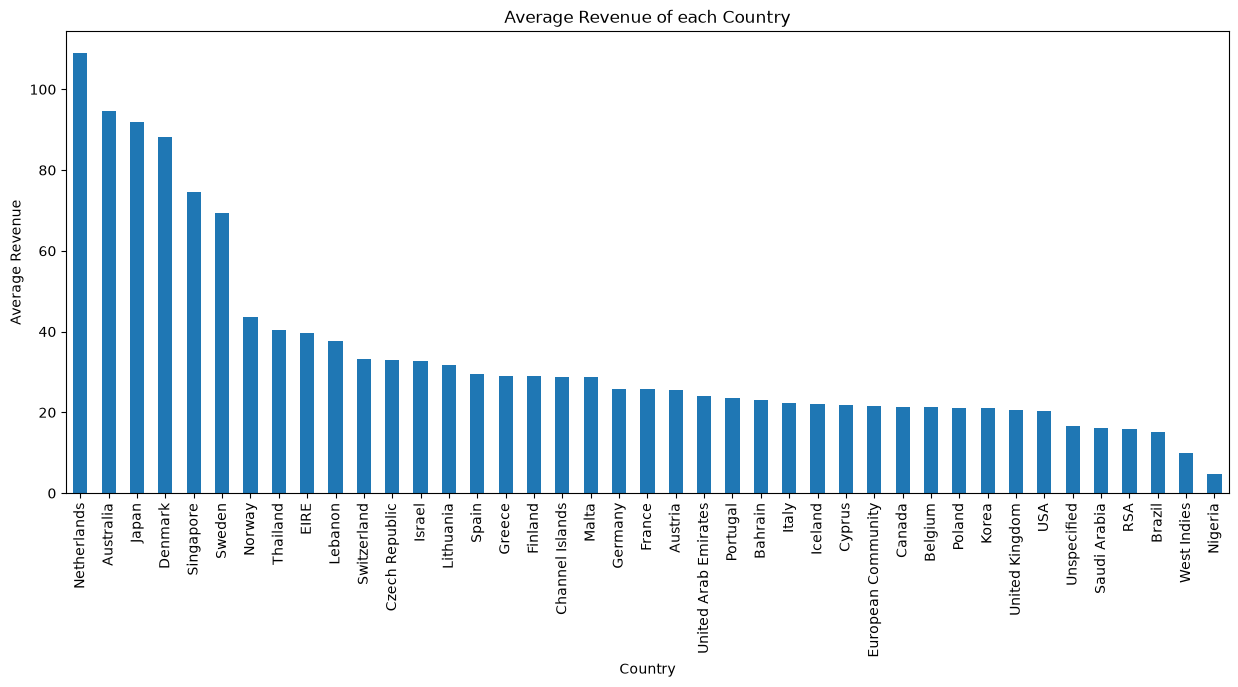

In [ ]:
country_sales = df.groupby("Country")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
country_sales.plot(kind="bar")
plt.ylabel("Average Revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Average Revenue of each Country")

plt.savefig("Average Revenue of each country")
plt.show()


3) This Graph shows the ascending order of the average revenue per month

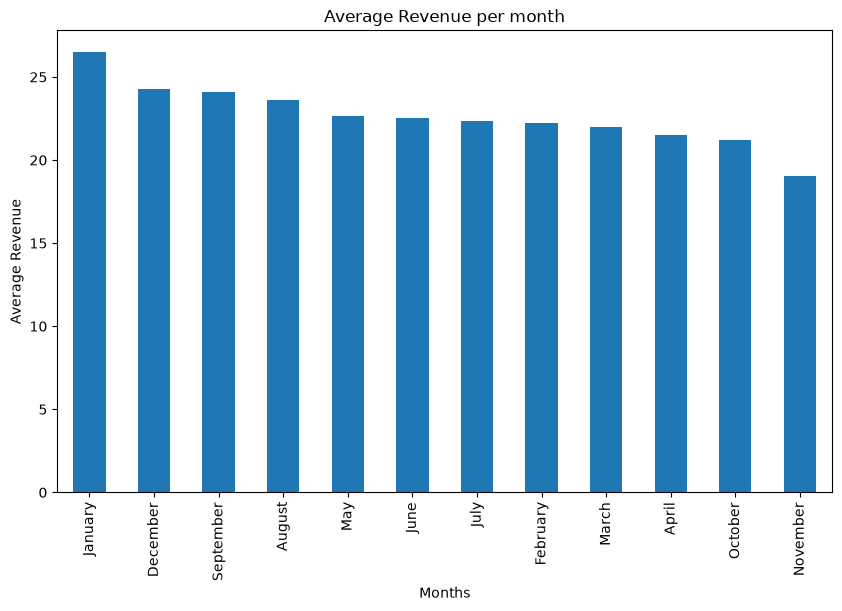

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
x = df["InvoiceDate"].dt.month_name()
Monthly_sales = df.groupby(x)["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
Monthly_sales.plot(kind="bar")
plt.ylabel("Average Revenue")
plt.xlabel("Months")
plt.title("Average Revenue per month")

plt.savefig("Average Revenue per month")
plt.show()

4) This Graph shows the ascending order of the average revenue of each day of week

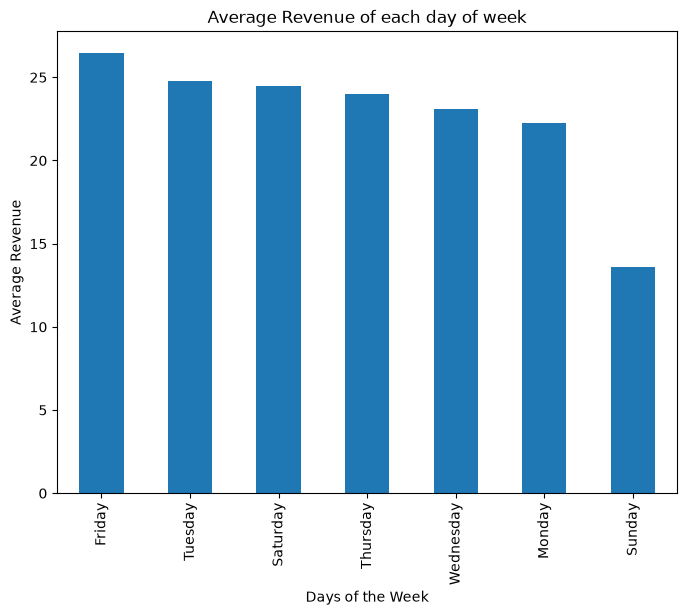

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
x = df["InvoiceDate"].dt.day_name()
Daily_sales = df.groupby(x)["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
Daily_sales.plot(kind="bar")
plt.ylabel("Average Revenue")
plt.xlabel("Days of the Week")
plt.title("Average Revenue of each day of week")

plt.savefig("Average Revenue of each day of week")
plt.show()

5) This Graph shows the top 10 products by quantity

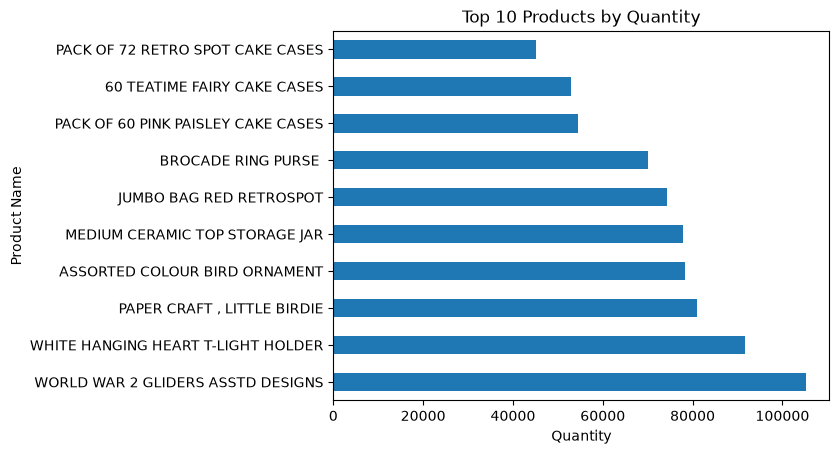

In [ ]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh")
plt.ylabel("Product Name")
plt.xlabel("Quantity")
plt.title("Top 10 Products by Quantity")
plt.savefig("Top 10 products by quantity")
plt.show()


6) This Graph shows the comparison between the one time customers and returing customers on basis of Average revnue

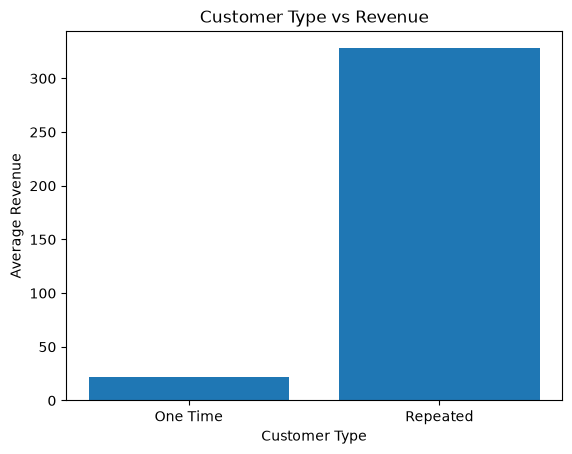

In [ ]:
x = df[df["CustomerType"] == "Repeated Customer"]["Revenue"].mean()
y = df[df["CustomerType"] != "Repeated Customer"]["Revenue"].mean()

plt.bar(["One Time", "Repeated"], [x, y])
plt.ylabel("Average Revenue")
plt.xlabel("Customer Type")
plt.title("Customer Type vs Revenue")

plt.savefig("Customer Type VS Revenue")
plt.show()

**Conclusion**:The average revenue of repeated customers are very high than the average revenue of one time customers

## Conclusion

The Online Retail dataset, after thorough cleaning (removal of missing values, duplicates, and invalid quantity/price records), reveals several important patterns:

1) Sales are highly skewed: A small number of transactions and products drive a large portion of total revenue. Extreme outliers (e.g., single orders of 70,000+ units) significantly influence overall figures.
2) Seasonality is clear: Total revenue peaks strongly in the last quarter of the year (especially November), indicating a strong pre-Christmas / holiday effect. Average revenue per transaction, however, is highest in January.
3) Customer value varies widely: A minority of customers contribute disproportionately high revenue. Repeated customers and one-time buyers also show different average order values, highlighting the importance of customer retention strategies.
4) Geographic concentration: Sales are heavily dominated by the United Kingdom, with other countries contributing smaller but still meaningful shares.
5) Product insights: A handful of items consistently rank among the top sellers by quantity, while a few high-priced or high-volume items dominate revenue.